In [1]:
import sys
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import yaml
import cv2
from datasets.fmd.data_loader import load_noisy_single_loader
from evaluation import get_largest_residual_indices
from evaluation.calibration_utils import (AnalysisManager, CalibrationManager,
                                          get_test_dataloader)
from models.checkpointing import load_checkpoint_for_inference, create_model, load_model_state
from QUTCC_eval import plot_visualization, create_single_pixel_pdf_plot


np.random.seed(0)
random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
# print("tmp folder: ", os.environ["TMPDIR"])

%matplotlib inline
%load_ext autoreload
%autoreload 2

Device: cuda


In [2]:
#Load in weights + calibration values
im2im_deep_folder = "experiments/mri/im2im_deep_epochs50_bs12_2025-10-18-14.18.46"

qutcc_folder = "experiments/mri/qutcc_epochs50_bs12_2025-10-18-10.07.36"

im2im_ckpt = os.path.join(im2im_deep_folder, 'checkpoints', 'epoch10.pth')
qutcc_ckpt = os.path.join(qutcc_folder, 'checkpoints', 'epoch10.pth')

# load jsons from the directories
with open(os.path.join(qutcc_folder, 'analysis', 'quantile_qs_epoch_5.json'), 'r') as f:
    qutcc_config = json.load(f)

# extracted this manually as the error bound was too high despite running for 10 epochs and failed to calculate bound
im2im_deep_lambda = 1.0110
upper_q = float(qutcc_config['upper_q'])
lower_q = float(qutcc_config['lower_q'])

noisy_image = "./QUTCC_eval/imgs/mri/noisy.png"
clean_image = "./QUTCC_eval/imgs/mri/clean.png"

noisy = torch.tensor(cv2.imread(noisy_image, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
ground_truth = torch.tensor(cv2.imread(clean_image, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0)

im2im_deep = create_model(net = "im2im_deep", device = device)
im2im_deep = load_model_state(im2im_deep, im2im_ckpt, device)

qutcc = create_model(net = "qutcc", device = device)
qutcc = load_model_state(qutcc, qutcc_ckpt, device)

Model state loaded from experiments/mri/im2im_deep_epochs50_bs12_2025-10-18-14.18.46/checkpoints/epoch10.pth
Model state loaded from experiments/mri/qutcc_epochs50_bs12_2025-10-18-10.07.36/checkpoints/epoch10.pth


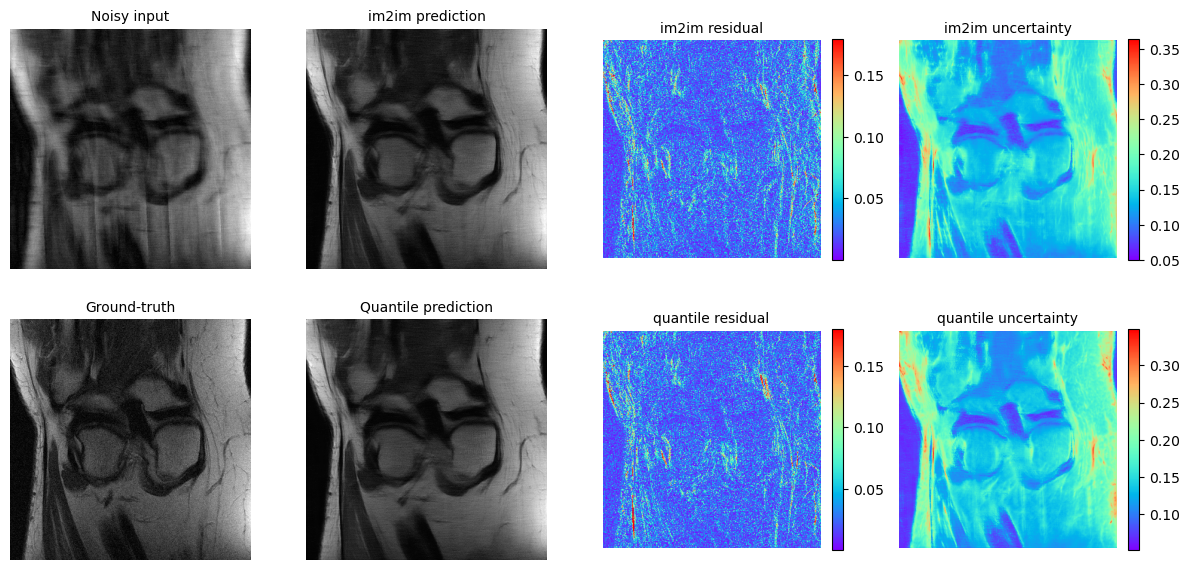

In [5]:
#Visualization
fig, ax = plot_visualization(noisy, ground_truth, im2im_model=im2im_deep, 
                    quantile_model=qutcc, im2im_lam=im2im_deep_lambda, lower_q=lower_q, upper_q=upper_q, 
                    device=device, exp_type="hi", save=False)
plt.show()

In [6]:
fig = create_single_pixel_pdf_plot(
    quantile_model = qutcc, 
    noisy_tensor = noisy, 
    quantile_levels = [0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95], 
    quantile_levels_conformal = 
    device = device,                               
    pixel_coord=tuple(int(x.strip()) for x in config['pixel_coord'].split(',')), 
    ylim=tuple(int(x.strip()) for x in config['ylim'].split(',')))


NameError: name 'quantile_levels' is not defined